<div style="border:2px solid #B3241C; background:#FDECEA; border-radius:8px; padding:16px 20px;">
  <div style="color:#B3241C; font-size:26px; font-weight:800; line-height:1.25; margin-bottom:8px;">
    STOP &mdash; do this first
  </div>
  <div style="font-size:19px; color:#1F2328; line-height:1.5;">
    <b>File &rarr; Save a copy in Drive</b>, then work in <b>your</b> copy.<br>
    If you skip this step, nothing you type here will be saved.
  </div>
</div>

# K513 Final Project · Notebook 1 — From eight files to one table

**Your goal in this notebook:** understand the eight raw tables, check how they relate, and build one
tidy table with **one row per delivered order** — the table Notebooks 2 and 3 run on.

**How this notebook works**

- The data loads from my github account; nothing to download. Run every cell from top to bottom, must be in this order with no skipping. Otherwise the numbers might not be correct even if there are no errors.
- Cells with `____` are yours to complete. Everything else runs as given.
- A line marked **📊 Slide N** tells you where the answer goes in the deck template
  (*K513 Final Project Deck Template*). The deck is where your answers are graded; this notebook is
  the evidence for every number in it.
- Section 6 ends with **checkpoints**. If your table matches them, you built it correctly. The same
  table is also provided as a file, so Notebooks 2 and 3 can start while this one is in progress.

## 0 · Load the data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)
pd.set_option('display.max_columns', 40)

BASE = "https://raw.githubusercontent.com/jl-uscn/k513-data/main/FP"

orders     = pd.read_csv(f"{BASE}/olist_orders.csv.gz")
items      = pd.read_csv(f"{BASE}/olist_order_items.csv.gz")
customers  = pd.read_csv(f"{BASE}/olist_customers.csv.gz")
products   = pd.read_csv(f"{BASE}/olist_products.csv.gz")
sellers    = pd.read_csv(f"{BASE}/olist_sellers.csv.gz")
payments   = pd.read_csv(f"{BASE}/olist_order_payments.csv.gz")
reviews    = pd.read_csv(f"{BASE}/olist_order_reviews.csv.gz")
categories = pd.read_csv(f"{BASE}/product_category_translation.csv.gz")

print("All eight tables loaded.")

---
## 1 · The eight tables

**Q1.1** For every table: how many rows and columns, and what is **one row**? Read the top 3 rows of
each table before you decide.

In [ ]:
tables = {'orders': orders, 'order_items': items, 'customers': customers,
          'products': products, 'sellers': sellers, 'payments': payments,
          'reviews': reviews, 'categories': categories}

for name, table in tables.items():
    print(f"{name:12s} {table.shape[0]:>7,} rows  {table.shape[1]:>2} columns")

In [ ]:
orders.head(3)

In [ ]:
# Look at the first rows of each of the other seven tables, one cell each.
items.head(3)

In [ ]:
____.head(3)

In [ ]:
____.head(3)

In [ ]:
____.head(3)

In [ ]:
____.head(3)

In [ ]:
____.head(3)

In [ ]:
____.head(3)

**Q1.2** Which column is the **unique identifier** of each table? A column is a unique identifier
when its number of unique values equals the number of rows in the table. The first one is done for you.

In [ ]:
print("orders     ", orders['order_id'].nunique(), "unique order_id  vs", len(orders), "rows")
print("customers  ", customers['____'].nunique(), "unique customer_id  vs", len(customers), "rows")
print("products   ", products['____'].nunique(), "unique product_id  vs", len(products), "rows")
print("sellers    ", sellers['____'].nunique(), "unique seller_id  vs", len(sellers), "rows")
print("reviews    ", reviews['____'].nunique(), "unique review_id  vs", len(reviews), "rows")
print("categories ", categories['____'].nunique(), "unique names  vs", len(categories), "rows")
print("order_items", items['order_id'].nunique(), "unique order_id  vs", len(items), "rows")
print("payments   ", payments['order_id'].nunique(), "unique order_id  vs", len(payments), "rows")

`order_id` is **not** unique in `order_items` or `payments`. When no single column is unique, a
**combination** of columns can be. `duplicated(subset=[...])` counts rows that repeat an earlier
row on those columns — zero means the combination is a unique identifier.

In [ ]:
print("order_items, order_id + order_item_id:  ",
      items.duplicated(subset=['order_id', '____']).sum(), "repeated rows")
print("payments, order_id + payment_sequential:",
      payments.duplicated(subset=['order_id', '____']).sum(), "repeated rows")

> 📊 **Slide 2** — fill in the table: for each of the eight tables, one row is ___, rows, columns,
> and its unique identifier (one column or a combination).

---
## 2 · Identifiers and dates

**Q2.1** The customers table has two columns ending with _id. Count the unique values of each. Which one
identifies a row of this table, and which one identifies a **customer**? How many customers placed the
40,000 orders, and how many of them ordered more than once?

In [ ]:
print("customer_id       ", customers['customer_id'].nunique())
print("customer_unique_id", customers['____'].____)

orders_per_customer = customers['customer_unique_id'].value_counts()
print("customers with more than one order:", (orders_per_customer > ____).sum())

**Q2.2** `review_id` looks like a unique identifier, but it is not — and the duplicates run in two
directions.

- **One `review_id` on several orders.** How many rows repeat an earlier `review_id`? Look at one
  repeated `review_id`: who placed its orders, and when? What does that suggest about how those
  orders were created?
- **One order with several `review_id`s.** How many orders carry more than one review? Look at one:
  when was each review created, and did the score change? Which review should the tidy table keep?

In [ ]:
print("rows that repeat an earlier review_id:", reviews.duplicated(subset='review_id').sum())
print("orders with more than one review:     ", (reviews['order_id'].value_counts() > ____).sum())

# One review_id attached to several orders
example_review = reviews.loc[reviews.duplicated(subset='review_id'), 'review_id'].iloc[0]
print("\nexample review_id that repeats:", example_review)
display(reviews[reviews['review_id'] == example_review][['review_id', 'order_id', 'review_score']]
        .merge(orders[['order_id', 'customer_id', 'order_purchase_timestamp']], on='order_id', how='left')
        .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left'))

# One order with several review_ids (one whose score changed)
reviews_per_order = reviews['order_id'].value_counts()
multi_review = reviews[reviews['order_id'].isin(reviews_per_order[reviews_per_order > 1].index)]
scores_per_order = multi_review.groupby('order_id')['review_score'].nunique()
example_order = scores_per_order[scores_per_order > 1].index[0]
print("example order_id that has multiple reviews:", example_order)
display(reviews[reviews['order_id'] == example_order]
        [['order_id', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp']]
        .sort_values('review_creation_date'))

> 📊 **Slide 3** — the customers table (Q2.1) and the reviews table (Q2.2).

**Q2.3** The `order_items` table has one row per **item line**. What does `order_item_id` count?
Look at the order with the most item lines: how many **different** products does it contain, and
does the same product appear more than once? There is no quantity column — so what does one row
stand for, and how should the **total revenue** and **total freight** of an order be calculated?

In [ ]:
biggest = items['order_item_id'].max()
example = items[items['order_item_id'] == biggest]['order_id'].iloc[0]
example_lines = items[items['order_id'] == example]
print("example order_id:", example)
print("largest order_item_id:", biggest)
example_lines[['order_item_id', 'product_id', 'seller_id', 'price', 'freight_value']]

In [ ]:
print("item lines:          ", len(example_lines))
print("different products:  ", example_lines['product_id'].____())
print("# of sellers:   ", example_lines['seller_id'].____(), "\n")
print("item lines per product:")
print(example_lines['product_id'].value_counts(), "\n")
print("total revenue (sum of price):        ", round(example_lines['price'].____(), 2))
print("total freight (sum of freight_value):", round(example_lines['____'].sum(), 2))

Is the example unusual? Count the orders where the **same product** appears on more than one item line.

In [ ]:
lines_per_order = items['order_id'].value_counts()
products_per_order = items.groupby('order_id')['product_id'].nunique()
repeats = (lines_per_order > products_per_order.reindex(lines_per_order.index)).sum()
print("orders with more than one item line:            ", (lines_per_order > ____).sum())
print("orders where the same product appears 2+ times: ", repeats)

> 📊 **Slide 4** — what `order_item_id` counts, the example order (lines, products, repeats), and how
> to calculate an order's revenue and freight, with the reason.

**Q2.4** The orders table has five dates, and all of them arrive as **strings**. Convert them to
dates, then count the missing values in each. Which order statuses have no delivery date?

In [ ]:
DATE_COLUMNS = ['order_purchase_timestamp', 'order_approved_at',
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

print(orders[DATE_COLUMNS].dtypes, "\n")
for col in DATE_COLUMNS:
    orders[col] = pd.to_datetime(orders[col])

print(orders[DATE_COLUMNS].isna().sum(), "\n")
print(orders['order_status'].value_counts())

In [ ]:
delivered_date_crosstab = pd.crosstab(orders['order_status'], orders['order_delivered_customer_date'].isna(),
            margins=True)
delivered_date_crosstab.rename(columns={True: 'Date Missing', False: 'Date Present'}, inplace=True)
display(delivered_date_crosstab)

**Q2.5** An order is **late** when it reached the customer after the date the customer was promised
at checkout:

```python
late = order_delivered_customer_date > order_estimated_delivery_date
```

Use this rule exactly — compare the full timestamps, not just the calendar dates. Which orders
**cannot** be labeled late or on time, and why?

In [ ]:
delivered = orders[(orders['order_status'] == '____')
                   & orders['order_delivered_customer_date'].notna()]
late = delivered['order_delivered_customer_date'] > delivered['____']
print("delivered orders with a delivery date:", len(delivered))
print("late:", late.sum(), f"({late.mean():.1%})")

> 📊 **Slide 5** — what each of the five dates means, the missing-value counts, the rule for
> *late*, and which orders cannot be labeled.

---
## 3 · How the tables relate, and what does not match

Study the entity diagram in the project brief: which column links each pair of tables? Before you
merge two tables, find out whether every row on each side has a match on the other side. A merge
with the wrong `how=` drops the rows without a match **silently** — no error, no warning.

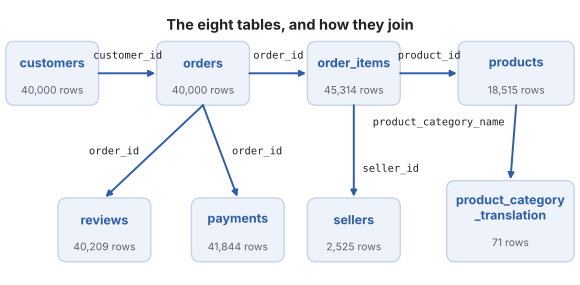

`indicator=True` (Week 2) labels every row of an outer merge: `both`, `left_only` or `right_only`.
The first check is done for you.

**Q3.1** Run the check for every pair of tables in the list below.

In [ ]:
# orders <-> order_items, on order_id
check = orders[['order_id']].merge(items[['order_id']].drop_duplicates(),
                                   on='order_id', how='outer', indicator=True)
print(check['_merge'].value_counts())

In [ ]:
pairs = [
    ('orders',      orders,    'order_items', items,     'order_id'),
    ('orders',      orders,    'customers',   customers, '____'),
    ('orders',      orders,    'payments',    payments,  '____'),
    ('orders',      orders,    'reviews',     reviews,   '____'),
    ('order_items', items,     'products',    products,  '____'),
    ('order_items', items,     'sellers',     sellers,   '____'),
    ('products',    products,  'categories',  categories, '____'),
]

for left_name, left, right_name, right, key in pairs:
    check = (left[[key]].drop_duplicates()
             .merge(right[[key]].drop_duplicates(), on=key, how='outer', indicator=True))
    counts = check['_merge'].value_counts()
    print(f"{left_name:11s} <-> {right_name:11s} on {key:21s}  rows in both tables: {counts['both']:>6,}   "
          f"only in {left_name:11s}: {counts['left_only']:>4}  only in {right_name:11s}: {counts['right_only']:>2}")

Read the last line carefully. A `NaN` category never matches anything, so
`drop_duplicates()` keeps one `NaN` and it shows up as *only in products*. Count the products with no
category separately, and list the category names that are missing from the translation table.

In [ ]:
print("products with no category:", products['product_category_name'].isna().sum())
untranslated = set(products['product_category_name'].dropna()) - set(categories['product_category_name'])
print("categories missing from the translation table:", sorted(untranslated))

**Q3.2** Which orders have no items? Look at their status. Will any of them matter for a model
that predicts late delivery?

In [ ]:
no_items = orders[~orders['order_id'].isin(items['____'])]
print("orders with no item lines:", len(no_items))
no_items['____'].value_counts()

> 📊 **Slide 6** — the table of checks: for each pair, how many rows have no partner on each side,
> and what you will do about each in Section 6. Answer: do all customers have orders? have all
> sellers sold something? have all products been ordered?

---
## 4 · Orders with more than one item

The tidy table has one row per order, so the item lines of each order have to be collapsed into one
row. `pivot_table` (Week 2) does this: `index=` is what one output row is, and `aggfunc=` says how
each column is summarized.

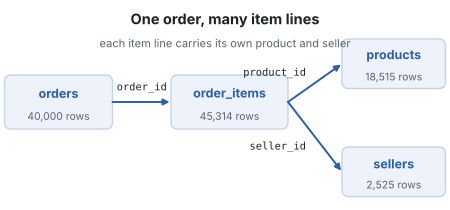

**Q4.1** How many orders have more than one item line? Of those, how many contain more than one
**different** product, and how many more than one **different** seller?

In [ ]:
per_order = items.pivot_table(index='order_id',
                              aggfunc={'order_item_id': 'count',
                                       'product_id': '____',
                                       'seller_id': '____'})
multi = per_order[per_order['order_item_id'] > 1]
print("orders with more than one item line:", len(multi))
print("  ...with more than one product:     ", (multi['product_id'] > ____).sum())
print("  ...with more than one seller:      ", (multi['seller_id'] > ____).sum())

**Q4.2** When an order with two sellers becomes one row, which seller does the row show? What
information is lost, and for how many orders?

> 📊 **Slide 7** — the three counts, and what is lost when items become one row per order.

---
## 5 · Sellers, customers and products

These questions need the item-level detail that the tidy table will no longer have, so answer them
here, from the raw tables.

The next cell builds a **seller-order** table: one row per seller per order, with whether that order
was delivered late and its review score. It is given to you — read it line by line.

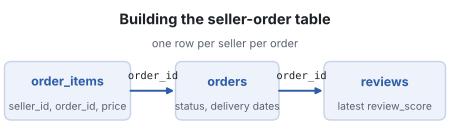

In [ ]:
# latest review per order (an order can carry more than one review)
latest_review = (reviews.sort_values('review_answer_timestamp')
                 .drop_duplicates(subset='order_id', keep='last')[['order_id', 'review_score']])

seller_orders = (items[['order_id', 'seller_id', 'price']]
                 .pivot_table(index=['seller_id', 'order_id'], values='price', aggfunc='sum')
                 .reset_index()
                 .merge(orders[['order_id', 'order_status', 'order_delivered_customer_date',
                                'order_estimated_delivery_date']], on='order_id', how='inner')
                 .merge(latest_review, on='order_id', how='left'))
seller_orders['late'] = (seller_orders['order_delivered_customer_date']
                         > seller_orders['order_estimated_delivery_date'])
seller_orders['bad_review'] = seller_orders['review_score'] <= 2
print(seller_orders.shape)
seller_orders.head()

**Q5.1** How many sellers are there? How are orders spread across them — do a few sellers supply
most of the orders? Find the share of all seller-orders that the top 10% of sellers account for.

In [ ]:
orders_per_seller = seller_orders['seller_id'].value_counts()
# Get the number of unique sellers
print("number of unique sellers:", ____)
# Get statistics of orders per seller using .describe()
print(____)

top_10pct = orders_per_seller.head(int(len(orders_per_seller) * ____))
print(f"\ntop 10% of sellers ({len(top_10pct)}) hold "
      f"{top_10pct.sum() / orders_per_seller.sum():.1%} of orders")

# Create a histogram of orders per seller using seaborn
sns.____
plt.xlabel('orders per seller')
plt.ylabel('# of sellers')
plt.show()

**Q5.2** What share of sellers had at least one late delivery? At least one bad review (score 1
or 2)? Then, among sellers with **at least 10 delivered orders**, list the 5 with the highest late
rate. These are candidate *problem sellers*.

In [ ]:
delivered_orders = seller_orders[(seller_orders['order_status'] == 'delivered')
                             & seller_orders['order_delivered_customer_date'].notna()]
by_seller = delivered_orders.groupby('seller_id').agg(
    n_delivered_orders=('order_id', '____'),
    late_rate=('late', 'mean'),
    bad_review_rate=('bad_review', 'mean'),
)
print('Number of orders, late delivery rate, and bad review rate per seller:')
display(by_seller.head(3))

print(f"sellers with at least one late delivery: {(by_seller['late_rate'] > 0).mean():.1%}")
print(f"sellers with at least one bad review:    {(by_seller['bad_review_rate'] > 0).mean():.1%}")

print("Top 5 sellers by late delivery rate with at least 10 delivered orders:")
(by_seller[by_seller['n_delivered_orders'] >= ____]
 .sort_values('____', ascending=False).head(5))

> 📊 **Slide 8** — number of sellers, the chart of orders per seller, the top-10% share, the two
> percentages, and your top 5 problem sellers (first 6 characters of each `seller_id` is enough).

**Q5.3** Where are the customers from? Make a bar chart of orders by `customer_state` (top 10 states).
Then compute revenue per customer (`customer_unique_id`) as the sum of `price` over their item lines,
and describe its distribution. Who are the top customers?

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=customers, y='____',
              order=customers['customer_state'].value_counts().index[:10])
plt.title('Top 10 States by Number of Orders')
plt.xlabel('number of orders')
plt.show()

revenue_per_customer = (items.merge(orders[['order_id', 'customer_id']], on='order_id', how='inner')
                      .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')
                      .pivot_table(index='customer_unique_id', values='price', aggfunc='____')['price'])
print("Revenue per customer:")
display(revenue_per_customer.head(3))
print(revenue_per_customer.describe().round(2))
revenue_per_customer.sort_values(ascending=False).head(5)

> 📊 **Slide 9** — the state chart, the number of repeat customers (from Q2.1), the distribution of
> revenue per customer (mean, median, and what the difference tells you), and the top customers.

**Q5.4** Which product categories sell most? Find the top 10 categories (English names) by number
of item lines and by revenue. Do the two lists agree?

In [ ]:
item_categories = (items.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
                   .merge(categories, on='product_category_name', how='left'))
item_categories['product_category_name_english'] = item_categories['product_category_name_english'].fillna('unknown')

by_category = item_categories.pivot_table(index='product_category_name_english',
                                          aggfunc={'order_item_id': '____', 'price': '____'})
by_category.columns = ['num_items', 'revenue']
print(by_category.sort_values('num_items', ascending=False).head(10), "\n")
print(by_category.sort_values('____', ascending=False).head(10))

> 📊 **Slide 10** — the two top-10 lists side by side, where they disagree, and the products with no
> category or no English name.

---
## 6 · Build the model-ready table

Five steps: collapse each multi-row table to **one row per order**, join them onto `orders`, keep the
orders that can be labeled, add the calculated columns, and check against the checkpoints.

### 6.1 · Items → one row per order

First bring product, category and seller details onto each item line. For the join,
every item line must survive, even one whose product has no category. Make sure you choose the correct join type. Print the row count before and
after every join — it must not change.

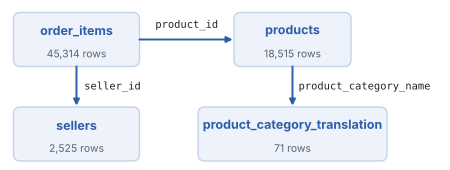

In [ ]:
print("item lines before:", len(items))
items_full = (items.merge(products, on='____', how='____')
                   .merge(categories, on='____', how='____')
                   .merge(sellers, on='____', how='____'))
print("item lines after: ", len(items_full))

items_full['category'] = items_full['product_category_name_english'].fillna('unknown')
print("item lines with category 'unknown':", (items_full['category'] == 'unknown').sum())

**Q6.1** What would an **inner** join to the translation table have done? Count the item lines and
the orders it would have dropped. (Section 6.5 tells you how many of those orders were delivered.)

In [ ]:
would_drop = items_full[items_full['product_category_name_english'].isna()]
print("item lines an inner join would drop:", len(would_drop))
print("orders affected:                    ", would_drop['order_id'].nunique())

Now collapse to one row per order. Each column needs its own summary: count the item lines, count the
**different** products and sellers, add up money and weight, and take the **largest** dimension of
any item (the bulkiest item is what makes a parcel hard to ship).

In [ ]:
items_by_order = items_full.pivot_table(
    index='order_id',
    aggfunc={'order_item_id': 'count',
             'product_id': 'nunique',
             'seller_id': '____',
             'price': '____',
             'freight_value': '____',
             'product_weight_g': '____',
             'product_length_cm': 'max',
             'product_height_cm': '____',
             'product_width_cm': '____'})

items_by_order = items_by_order.rename(columns={
    'order_item_id': 'n_items', 'product_id': 'n_diff_products', 'seller_id': 'n_diff_sellers',
    'price': 'revenue', 'freight_value': 'freight', 'product_weight_g': 'total_weight_g',
    'product_length_cm': 'max_length_cm', 'product_height_cm': 'max_height_cm',
    'product_width_cm': 'max_width_cm'}).reset_index()
print(items_by_order.shape)
items_by_order.head(3)

Seller and category cannot be added up. The table keeps them from the **first item line** of each
order (`order_item_id == 1`) — a rule, not the truth, for the orders you counted in Q4.1.

In [ ]:
first_item = items_full[items_full['order_item_id'] == 1][
    ['order_id', 'seller_id', 'seller_city', 'seller_state', 'category']]
print("first item lines:", len(first_item), "for", items_full['order_id'].nunique(), "orders")
items_by_order = items_by_order.merge(first_item, on='order_id', how='inner')
print(items_by_order.shape)

> 📊 **Slide 11** — the item-line joins: the join type and row count after each one, and after
> collapsing to one row per order; which tables reach orders only through `order_items`, and why the
> item lines must be collapsed before joining onto `orders`.

### 6.2 · Payments → one row per order

Add up `payment_value`, keep the largest number of installments, and keep the `payment_type` of the
**largest** payment.

In [ ]:
pay_totals = payments.pivot_table(index='order_id',
                                  aggfunc={'payment_value': '____', 'payment_installments': '____'})
main_type = (payments.sort_values('payment_value', ascending=False)
             .drop_duplicates(subset='order_id', keep='first')[['order_id', 'payment_type']])
payments_by_order = pay_totals.reset_index().merge(main_type, on='order_id', how='inner')
print(payments_by_order.shape)

### 6.3 · Reviews → one row per order

Count the reviews, and keep the score of the **latest** one (the review answered last).

In [ ]:
n_reviews = reviews.pivot_table(index='order_id', values='review_id', aggfunc='____')
n_reviews = n_reviews.rename(columns={'review_id': 'n_reviews'}).reset_index()
reviews_by_order = n_reviews.merge(latest_review, on='order_id', how='inner')
print(reviews_by_order.shape)

### 6.4 · Join everything onto orders

Orders with no item lines cannot be late or reviewed (Q3.2), so this join is an **inner** join on
purpose — and you report how many orders it drops. The other three tables have a partner for every
order (Q3.1). Print the row count after every join.

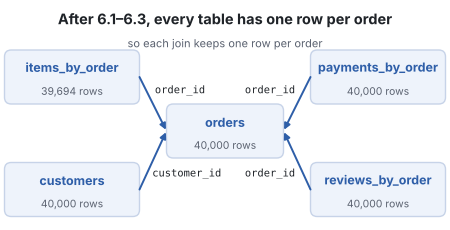

In [ ]:
print("orders:                 ", len(orders))
tidy = orders.merge(items_by_order, on='order_id', how='____')
print("after items (inner):    ", len(tidy), "  dropped", len(orders) - len(tidy))
tidy = tidy.merge(customers, on='____', how='inner')
print("after customers (inner):", len(tidy))
tidy = tidy.merge(payments_by_order, on='order_id', how='left')
print("after payments (left):  ", len(tidy))
tidy = tidy.merge(____, on='order_id', how='left')
print("after reviews (left):   ", len(tidy))

**Checkpoint 1** — this cell prints *passed* only if your joined table is right.

In [ ]:
assert len(tidy) == 39_694, f"expected 39,694 rows, got {len(tidy):,}"
assert tidy['order_id'].is_unique, "some order appears more than once — check your aggregation"
print("Checkpoint 1 passed: 39,694 orders, one row each")

### 6.5 · Keep the orders that can be labeled

Keep delivered orders that have a delivery date (Q2.5). Report how many rows this drops, by status.

In [ ]:
labeled = tidy[(tidy['order_status'] == '____')
               & tidy['order_delivered_customer_date'].notna()].copy()
print("before:", len(tidy), "  after:", len(labeled), "  dropped:", len(tidy) - len(labeled))
print("Status of dropped orders:")
print(tidy[~tidy.index.isin(labeled.index)]['order_status'].value_counts())
print("\ndelivered orders an inner join to the translation table would have lost:",
      labeled['order_id'].isin(would_drop['order_id']).sum())

### 6.6 · Add the calculated columns

Use these definitions exactly, so your table matches the provided one. `.dt.days` gives whole days,
rounded **down** — so an order 3 hours late has `n_days_ahead` of −1.

| Column | Meaning |
|---|---|
| `n_days_promised` | days from purchase to the promised delivery date |
| `n_days_to_carrier` | days from purchase to the seller handing the parcel to the carrier |
| `n_days_ahead` | days the order arrived **before** the promised date — negative means late |
| `late` | 1 if delivered after the promised date, else 0 |
| `same_city`, `same_state` | 1 if customer and (first) seller are in the same city / state |

In [ ]:
labeled['n_days_promised'] = (labeled['order_estimated_delivery_date']
                              - labeled['order_purchase_timestamp']).dt.days
labeled['n_days_to_carrier'] = (labeled['____']
                                - labeled['order_purchase_timestamp']).dt.days
labeled['n_days_ahead'] = (labeled['order_estimated_delivery_date']
                           - labeled['____']).dt.days
labeled['late'] = (labeled['order_delivered_customer_date']
                   > labeled['order_estimated_delivery_date']).astype(int)
labeled['same_city'] = (labeled['customer_city'] == labeled['____']).astype(int)
labeled['same_state'] = (labeled['customer_state'] == labeled['____']).astype(int)

### 6.7 · Select the columns, check, and save

In [ ]:
FINAL_COLUMNS = [
    'order_id', 'customer_unique_id', 'seller_id',
    'order_purchase_timestamp', 'order_estimated_delivery_date',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'customer_city', 'customer_state', 'seller_city', 'seller_state', 'same_city', 'same_state',
    'category', 'n_items', 'n_diff_products', 'n_diff_sellers',
    'revenue', 'freight', 'total_weight_g', 'max_length_cm', 'max_height_cm', 'max_width_cm',
    'payment_type', 'payment_installments', 'payment_value',
    'n_reviews', 'review_score',
    'n_days_promised', 'n_days_to_carrier', 'n_days_ahead', 'late']

model_ready = labeled[FINAL_COLUMNS].reset_index(drop=True)
print(model_ready.shape)

**Checkpoint 2** — compares your table with the checkpoint numbers.

In [ ]:
assert model_ready.shape == (38_811, 32), f"expected (38811, 32), got {model_ready.shape}"
assert model_ready['late'].sum() == 3_166, f"expected 3,166 late orders, got {model_ready['late'].sum():,}"
assert model_ready['n_items'].sum() == 44_315, f"expected 44,315 item lines, got {model_ready['n_items'].sum():,}"
assert (model_ready['category'] == 'unknown').sum() == 592, "category: did you fill missing names with 'unknown'?"
print("Checkpoint 2 passed: 38,811 orders, 32 columns, 3,166 late (8.2%)")

In [ ]:
model_ready.to_csv('olist_model_ready.csv', index=False)
print("saved olist_model_ready.csv — find it in the Files panel on the left")

> 📊 **Slide 12** — the join sequence: the row count after every step, every group of rows that was
> dropped and why, and what an inner join to the translation table would have cost.
>
> 📊 **Slide 13** — the aggregation rules: for `order_items`, `payments` and `reviews`, which columns
> you kept and how each one was summarized (count, number of different values, sum, max, first, latest).

---
### Before you submit

- [ ] Runtime → **Restart and run all** finishes with no errors and both checkpoints pass
- [ ] Every 📊 slide above (2–13) is filled in the deck
- [ ] Your finding for slide 39, the team summary, is agreed with your team
- [ ] File → Download → **Download .ipynb**, and upload that file to Canvas. Download *after* the run above, so the file includes every output